In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np
from jax import random
import seaborn as snb

from bayesian import *

# use 64-bit precision
from jax import config
config.update("jax_enable_x64", True)

# style stuff
snb.set_style('darkgrid')
snb.set_theme(font_scale=1.25)
colors = snb.color_palette()

# 02477 Bayesian Machine Learning Exam Template

# Part 1
Solution to Q1.1 through Q1.3: See handwritten solution on appendix A

In [53]:
# Part 1

# We apply the results shown in appendix A and print the mean vectors and covariance matrices of the distributions.
A = jnp.array([0, 1, 1, 0]).reshape((2,2))
b = jnp.ones((2,))
W = jnp.array([1, 1, 1, 0]).reshape((2,2))

# Q1.2
Sigma_xz = jnp.linalg.inv(jnp.eye(2) + 2*A.T @ A)
# print(f'p(z|x): mu = {:3.5f}, Sigma = {jnp.eye(2) + 2*A.T @ A}')
# Maybe look into printing it with sympy?
# print(Sigma_xz @ A.T * 2)

# Q1.3
Sigma_y = 1/2 * jnp.eye(2) + W @ (1/2 * jnp.eye(2) + A @ A.T) @ W.T
print(Sigma_y)

[[3.5 1.5]
 [1.5 2. ]]


# Part 2
Solution to Q2.1 through Q2.5: See handwritten solution on appendix B

In [55]:
# Part 2
# Define problem variables
X = jnp.array([0,0,1,1]).T.reshape((2,2))
y = jnp.array([0,1])
w_map = jnp.array([1,1])*0.74077439
x_star = jnp.arange(2)
lambda1 = 1/4

#plot_data(X, y)

# Q2.1 Apply the plugin approximation using the given map estimate.
from bayesian import sigmoid
p = sigmoid(w_map @ x_star)
print(f'p(y*|y, x*): Ber({p:3.5f})') 
# This checks out when looking at the dataset

# Q2.2
log_npdf = lambda x, m, v: -(x-m)**2/(2*v) - 0.5*jnp.log(2*jnp.pi*v) # v is the variance
npdf = lambda x, m, v: jnp.exp(log_npdf(x, m, v))
# Evaluate the log joint for the given dataset, i.e. over all datapoints.


p = sigmoid(X @ w_map)
bernoulli_logpmf(y, p)
log_p_yw = bernoulli_logpmf(y, p).sum() + log_npdf(w_map, 0, lambda1**-1).sum()
print(f'log p(y,w) =  {log_p_yw:3.5f})') # I get the same value

#Q2.3

from jax import hessian
from scipy.optimize import minimize


neg_log_lik = lambda w: -(bernoulli_logpmf(y, sigmoid(X @ w)).sum() + log_npdf(w, 0, lambda1**-1).sum())
w_map_true = minimize(neg_log_lik, jnp.zeros(2))
#print(w_map_true)
log_lik = lambda w: (bernoulli_logpmf(y, sigmoid(X @ w)).sum() + log_npdf(w, 0, lambda1**-1).sum())


pos_hessian = hessian(log_lik)(w_map)
print(pos_hessian)

p(y*|y, x*): Ber(0.67717)
log p(y,w) =  -4.25931)
[[-0.40089693 -0.15089693]
 [-0.15089693 -0.40089693]]


In [5]:
# Q2.4
# First we determine the laplace approximation.
m, S = laplace_approximation(log_lik, jnp.zeros(2))
m = w_map 
S = -jnp.linalg.inv(pos_hessian) 
# Since the posterior predictive distribution is intractable for this model, we can either sample from the approximate posterior nd make a monte carlo estimate or
# we can apply the probit approximation. For now we apply the probit approximation.

# compute p(f^*|y, x^*)
fstar_mean = x_star @ w_map
fstar_var = x_star.T@S@x_star
print(f'p(f^*|y) = N(f^*|{fstar_mean:3.2f}, {fstar_var:3.2f})')
# compute p(y^*|y, x^*)
import scipy
Phi = scipy.stats.norm.cdf
p_ystar1 = Phi(fstar_mean/np.sqrt(8/np.pi + fstar_var))
print(f'p(y^* = 1|y, x^*=[0, 1].T) = {p_ystar1:3.2f} (probit approximation)')

# Q2.5

p(f^*|y) = N(f^*|0.74, 2.91)
p(y^* = 1|y, x^*=[0, 1].T) = 0.62 (probit approximation)


# Q2.5
First we note that the new target variable $z \in \mathbb{N}$ and as such this is a natural number regression task. 
In this case I would change the likelyhood to follow a poisson distribution parameterized by exp(x(n)@w) (such that the parameters are always positive). I would  keep the same prior on the weights.
One could consider making the model more complex by mapping x through some feature transformation to include second and higher order dependencies
in the regression model.  

Could also use softplus etc.

# Part 3
Solution to Q3.1 through Q3.5: See handwritten solution on appendix C

In [6]:
# Part 3


# Part 4
Solution to Q4.1 through Q4.5: See handwritten solution on appendix D

In [74]:
# Part 4
m = jnp.array([-0.87, 2.13])
S = jnp.array([0.41, 0.11, 0.11, 0.27]).reshape((2,2))

# Q4.1
# By the symmetry of prior distribution of w1 around the mean w1=0, easily see that
# the prior probability p(w1>0) = 0.5
# To compute the posterior probability, we compute the quantiles for the posterior destriubution of w1
scipy.stats.norm.cdf(0, loc = m[0], scale = jnp.sqrt(S[0,0])) 
# This is makes sense as the 0 is about 2 standard deviations out form the mean.
print(f'p(w1 > 0|y) = {(1- scipy.stats.norm.cdf(0, loc = m[0], scale = jnp.sqrt(S[0,0])) ):3.4f} ')

# Q4.2
print(f' 80% credibility interval for p(w2|y): {scipy.stats.norm.interval(confidence=0.80, loc = m[1], scale = jnp.sqrt(S[1,1]))}')

# Q4.3
x_star = 1
# This is a linear transformation of gaussians, thus f* is also a gaussian. We apply the equations from Murphy 1 3.3
A = jnp.ones(2)
mu = A @ m
Sigma = A @ S @ A.T
print(f'p(f*|y, x*): mu = {mu:3.5f}, Sigma = {Sigma}')

# Q4.4
# This is the same just with added measurement noise. Agian we refer to Murphy 3.3 for linear systems of Gaussians
sigma2 = jnp.sqrt(2)
print(f'p(f*|y, x*): mu = {mu:3.5f}, Sigma = {Sigma + sigma2}')

# Q4.5
# We apply a new model with heteroscedastic noise
# We approximate the posterior with a mean field gaussian.


compute_entropy = lambda v : 0.5 * jnp.sum(jnp.log(2 * jnp.pi * v) + 1.0)
v = jnp.array([0.38, 0.19, 0.13, 0.09])
mu = jnp.array([-0.82, 2.37, -0.88, 0.37])
entropy = compute_entropy(v)
print(f'H(q)= {entropy:3.5f}')

# Q4.6
y_star = 1
x_star = jnp.array([1, 1]) # add a 1 term to the first entry for the intercept
n_samples = 100000
from bayesian import mvn_sample
key = random.key(1)
w = mvn_sample(key, mu, jnp.diag(v), (n_samples))
w_samples = mu + jnp.sqrt(v)*random.normal(key, shape=(n_samples, 4))
y_star_mus = w[:, :2] @ x_star
y_star_vars = jnp.exp(w[:, 2:] @ x_star)

# For each of these values, evaluate the density of p(y*|y,x*)
# Simulate the full distribution 
y_stars = mvn_sample(key, y_star_mus, jnp.diag(y_star_vars), (1))
#plt.hist(y_stars[0], bins= 100, density=True)
# Using the plot as a sanity check, it seems that the density at y_star is about 0.35
print(npdf(1, y_star_mus, y_star_vars).mean())
# The two calculations agree.

npdf = lambda x, m, v: np.exp(log_npdf(x, m, v))
vals = npdf(1, w_samples[:, 0] + w_samples[:, 1], jnp.exp(w_samples[:, 2] + w_samples[:, 3]))
print(f'p(y^* = 1|y, x*) = {jnp.mean(vals):3.2f}')


p(w1 > 0|y) = 0.0871 
 80% credibility interval for p(w2|y): (np.float64(1.4640862727871946), np.float64(2.795913727212805))
p(f*|y, x*): mu = 1.26000, Sigma = 0.9
p(f*|y, x*): mu = 1.26000, Sigma = 2.3142135623730953
H(q)= 2.13751
0.3206138652605733
p(y^* = 1|y, x*) = 0.32


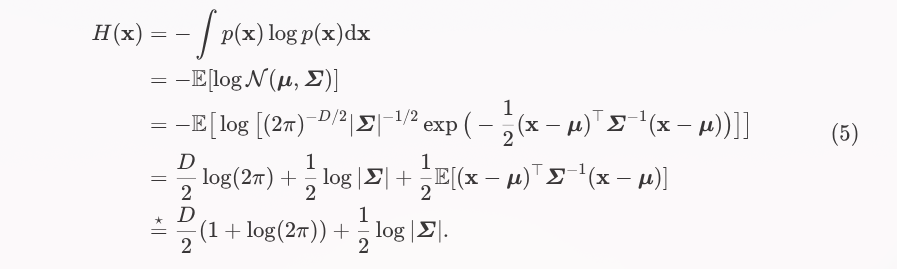

# Part 5
Solution to Q5.1 through Q5.5: See handwritten solution on appendix E

MCMC done: accept_rate=0.540  t=4.6s
(9001, 2)


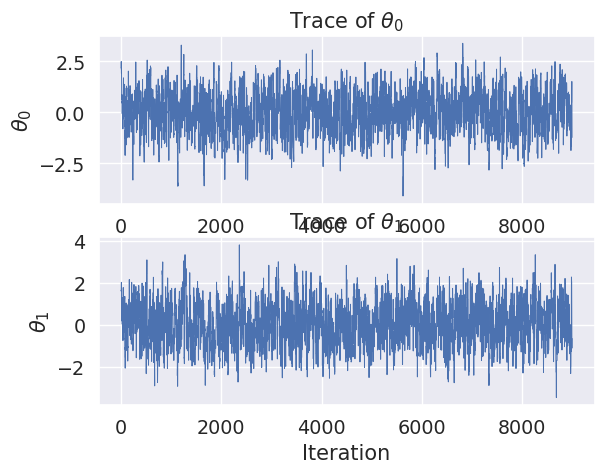

In [76]:
# Part 5
from bayesian import metropolis
sigma2 = 2
x1 = 1
y1 = 2

f = lambda w , x: w[1] * jnp.tanh(w[0] * x)
log_lik = lambda w : log_npdf(y1, f(w, x1), sigma2) + log_npdf(w, 0, 1).sum() # log likelyhood. Proportional to the posterior
num_iterations = 10000
warm_up = num_iterations//10
tau = 1
thetas = metropolis(log_lik, 2, tau, num_iterations, theta_init=jnp.zeros(2))
thetas = thetas[warm_up:]
print(thetas.shape)
fig, ax = plt.subplots(2,1)
plot_trace(ax, thetas)

# thetas = HMC(log_lik, num_iterations, theta0=jnp.zeros(2))


p(f(x*) > 1) = 0.20398
p(y*|y1, x*): mu = 0.37856
p(y*|y1, x*): 95% interval = [-2.7678402   3.52004498]
0.3785605155796308 0.39451701616142104


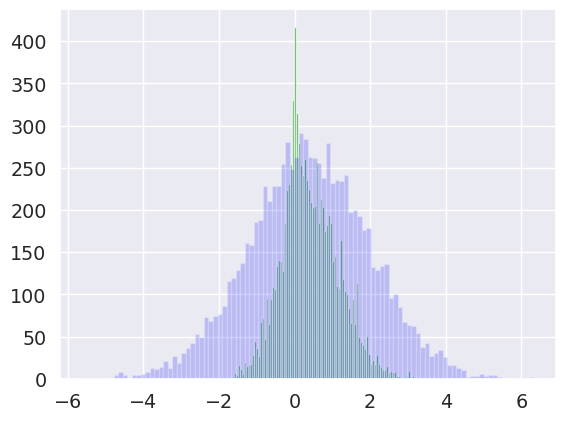

In [77]:
# Q5.2
x_star = 2
fs = jnp.array([f(theta, x_star) for theta in thetas])

print(f'p(f(x*) > 1) = {(fs > 1).mean():3.5f}')

# Q5.3
# Estimate the distribution p(y*|y1, x*)
# We have samples from p(f*|y1, x*). To get samples from p(y*|y1, x*) we can apply ancestral sampling and sample a random noise for each simulated y* sample.
eps = random.normal(key, fs.shape) * jnp.sqrt(sigma2)
bins = 100
plt.hist(fs, bins = 100, color = "green", alpha = 0.7)
y_stars = fs + eps
plt.hist(y_stars, bins = 100, color = "blue", alpha = 0.2)

print(f'p(y*|y1, x*): mu = {y_stars.mean():3.5f}')
interval = jnp.percentile(y_stars, jnp.array([2.5, 97.5]))
print(f'p(y*|y1, x*): 95% interval = {jnp.percentile(y_stars, jnp.array([2.5, 97.5]))}')


print(y_stars.mean(), fs.mean()) #  These two values should be equal in expectation.



In [78]:
from bayesian import plot_predictions
x_stars = jnp.linspace(0, 5, 10)
fs = jnp.array([[f(theta, x_star) for theta in thetas] for x_star in x_stars]).T
eps = random.normal(key, fs.shape) * jnp.sqrt(sigma2)
y_stars = fs + eps



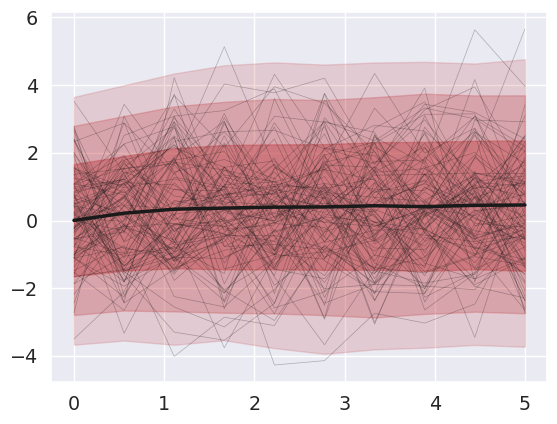

In [79]:
fig, ax = plt.subplots(1, 1)
plot_predictions(ax, x_stars, y_stars) # Behaves more or less the same over the x domain for this very simple posterior.